Imports et connexion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings("ignore")

load_dotenv()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"]      = 12

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:"
    f"{os.getenv('POSTGRES_PASSWORD')}@localhost:5432/"
    f"{os.getenv('POSTGRES_DB')}"
)

df_scrutins = pd.read_sql("SELECT * FROM scrutins ORDER BY date", engine)
df_scrutins["date"]   = pd.to_datetime(df_scrutins["date"])
df_scrutins["adopte"] = df_scrutins["adopte"].apply(
    lambda x: True if x is True or x == 1 or str(x).lower() == "true" else False
)

print(f"✅ {len(df_scrutins):,} scrutins chargés")
print(f"   Période : {df_scrutins['date'].min().date()} "
      f"→ {df_scrutins['date'].max().date()}")
print(f"   Adoptés : {df_scrutins['adopte'].sum():,} "
      f"({df_scrutins['adopte'].mean()*100:.1f}%)")
print(f"   Rejetés : {(~df_scrutins['adopte']).sum():,} "
      f"({(~df_scrutins['adopte']).mean()*100:.1f}%)")

✅ 6,899 scrutins chargés
   Période : 2024-10-08 → 2026-05-22
   Adoptés : 2,434 (35.3%)
   Rejetés : 4,465 (64.7%)


Statistiques descriptives scrutins

In [2]:
print("── STATISTIQUES DESCRIPTIVES   SCRUTINS ───────────")

cols_num = ["pour", "contre", "abstention", "non_votant",
            "total_votants", "taux_participation"]

metriques = {
    "Count":    lambda x: x.count(),
    "Mean":     lambda x: x.mean(),
    "Std":      lambda x: x.std(),
    "Min":      lambda x: x.min(),
    "Q25":      lambda x: x.quantile(0.25),
    "Median":   lambda x: x.median(),
    "Q75":      lambda x: x.quantile(0.75),
    "Max":      lambda x: x.max(),
    "Skewness": lambda x: x.skew(),
    "Kurtosis": lambda x: x.kurtosis(),
}

stats_df = pd.DataFrame({
    col: {name: func(df_scrutins[col].dropna())
          for name, func in metriques.items()}
    for col in cols_num
})
print(stats_df.round(2).to_string())

# Test de différence : votes Pour vs Contre
pour   = df_scrutins["pour"].dropna()
contre = df_scrutins["contre"].dropna()
t_stat, p_ttest = ttest_ind(pour, contre)
u_stat, p_mwu   = mannwhitneyu(pour, contre, alternative="two-sided")

print(f"\n── TESTS : VOTES POUR vs CONTRE ────────────────────")
print(f"   Moyenne Pour   : {pour.mean():.1f} | Médiane : {pour.median():.0f}")
print(f"   Moyenne Contre : {contre.mean():.1f} | Médiane : {contre.median():.0f}")
print(f"   t-test         : t={t_stat:.3f} | p={p_ttest:.4f} "
      f"({'significatif ✓' if p_ttest < 0.05 else 'non significatif'})")
print(f"   Mann-Whitney U : U={u_stat:.0f} | p={p_mwu:.4f} "
      f"({'significatif ✓' if p_mwu < 0.05 else 'non significatif'})")

── STATISTIQUES DESCRIPTIVES   SCRUTINS ───────────
             pour   contre  abstention  non_votant  total_votants  taux_participation
Count     6899.00  6899.00     6899.00     6899.00        6899.00             6899.00
Mean        69.19    76.01        9.10        3.07         154.30               26.74
Std         52.80    54.17       17.92        3.83          80.23               13.90
Min          0.00     0.00        0.00        0.00          16.00                2.80
Q25         35.00    34.00        1.00        1.00          95.00               16.50
Median      57.00    70.00        3.00        2.00         142.00               24.60
Q75         87.00   110.00        8.00        2.00         201.00               34.80
Max        560.00   404.00      257.00       22.00         574.00               99.50
Skewness     2.57     0.77        3.78        2.59           1.19                1.19
Kurtosis    11.85     0.77       20.00        5.13           2.84                2.84

─

Statistiques descriptives scrutins

In [3]:
print("── STATISTIQUES DESCRIPTIVES   SCRUTINS ───────────")

cols_num = ["pour", "contre", "abstention", "non_votant",
            "total_votants", "taux_participation"]

metriques = {
    "Count":    lambda x: x.count(),
    "Mean":     lambda x: x.mean(),
    "Std":      lambda x: x.std(),
    "Min":      lambda x: x.min(),
    "Q25":      lambda x: x.quantile(0.25),
    "Median":   lambda x: x.median(),
    "Q75":      lambda x: x.quantile(0.75),
    "Max":      lambda x: x.max(),
    "Skewness": lambda x: x.skew(),
    "Kurtosis": lambda x: x.kurtosis(),
}

stats_df = pd.DataFrame({
    col: {name: func(df_scrutins[col].dropna())
          for name, func in metriques.items()}
    for col in cols_num
})
print(stats_df.round(2).to_string())

# Test de différence : votes Pour vs Contre
pour   = df_scrutins["pour"].dropna()
contre = df_scrutins["contre"].dropna()
t_stat, p_ttest = ttest_ind(pour, contre)
u_stat, p_mwu   = mannwhitneyu(pour, contre, alternative="two-sided")

print(f"\n── TESTS : VOTES POUR vs CONTRE ────────────────────")
print(f"   Moyenne Pour   : {pour.mean():.1f} | Médiane : {pour.median():.0f}")
print(f"   Moyenne Contre : {contre.mean():.1f} | Médiane : {contre.median():.0f}")
print(f"   t-test         : t={t_stat:.3f} | p={p_ttest:.4f} "
      f"({'significatif ✓' if p_ttest < 0.05 else 'non significatif'})")
print(f"   Mann-Whitney U : U={u_stat:.0f} | p={p_mwu:.4f} "
      f"({'significatif ✓' if p_mwu < 0.05 else 'non significatif'})")

── STATISTIQUES DESCRIPTIVES   SCRUTINS ───────────
             pour   contre  abstention  non_votant  total_votants  taux_participation
Count     6899.00  6899.00     6899.00     6899.00        6899.00             6899.00
Mean        69.19    76.01        9.10        3.07         154.30               26.74
Std         52.80    54.17       17.92        3.83          80.23               13.90
Min          0.00     0.00        0.00        0.00          16.00                2.80
Q25         35.00    34.00        1.00        1.00          95.00               16.50
Median      57.00    70.00        3.00        2.00         142.00               24.60
Q75         87.00   110.00        8.00        2.00         201.00               34.80
Max        560.00   404.00      257.00       22.00         574.00               99.50
Skewness     2.57     0.77        3.78        2.59           1.19                1.19
Kurtosis    11.85     0.77       20.00        5.13           2.84                2.84

─

Détection outliers scrutins

In [4]:
print("── DÉTECTION DES OUTLIERS   MÉTHODE IQR ───────────")

def detecter_outliers_iqr(serie, nom):
    serie     = serie.dropna()
    Q1        = serie.quantile(0.25)
    Q3        = serie.quantile(0.75)
    IQR       = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    outliers  = serie[(serie < borne_inf) | (serie > borne_sup)]
    print(f"\n   {nom}")
    print(f"   Q1={Q1:.1f} | Q3={Q3:.1f} | IQR={IQR:.1f}")
    print(f"   Bornes : [{borne_inf:.1f}, {borne_sup:.1f}]")
    print(f"   Outliers : {len(outliers)} ({len(outliers)/len(serie)*100:.1f}%)")
    return outliers

detecter_outliers_iqr(df_scrutins["pour"], "Votes Pour")
detecter_outliers_iqr(df_scrutins["contre"], "Votes Contre")
detecter_outliers_iqr(df_scrutins["taux_participation"], "Participation")

print(f"\n── DÉCISION ────────────────────────────────────────")
print(f"   Tous les outliers conservés   scrutins légitimes")
print(f"   Les valeurs extrêmes reflètent des votes historiques réels")

── DÉTECTION DES OUTLIERS   MÉTHODE IQR ───────────

   Votes Pour
   Q1=35.0 | Q3=87.0 | IQR=52.0
   Bornes : [-43.0, 165.0]
   Outliers : 367 (5.3%)

   Votes Contre
   Q1=34.0 | Q3=110.0 | IQR=76.0
   Bornes : [-80.0, 224.0]
   Outliers : 86 (1.2%)

   Participation
   Q1=16.5 | Q3=34.8 | IQR=18.3
   Bornes : [-10.9, 62.2]
   Outliers : 114 (1.7%)

── DÉCISION ────────────────────────────────────────
   Tous les outliers conservés   scrutins légitimes
   Les valeurs extrêmes reflètent des votes historiques réels


Export données nettoyées

In [5]:
df_scrutins["ecart"] = abs(df_scrutins["pour"] - df_scrutins["contre"])

os.makedirs("../data/processed", exist_ok=True)
df_scrutins.to_csv(
    "../data/processed/scrutins_clean.csv",
    index=False, encoding="utf-8"
)
print(f"✅ scrutins_clean.csv exporté ({len(df_scrutins):,} lignes)")

✅ scrutins_clean.csv exporté (6,899 lignes)


Taux de rejet

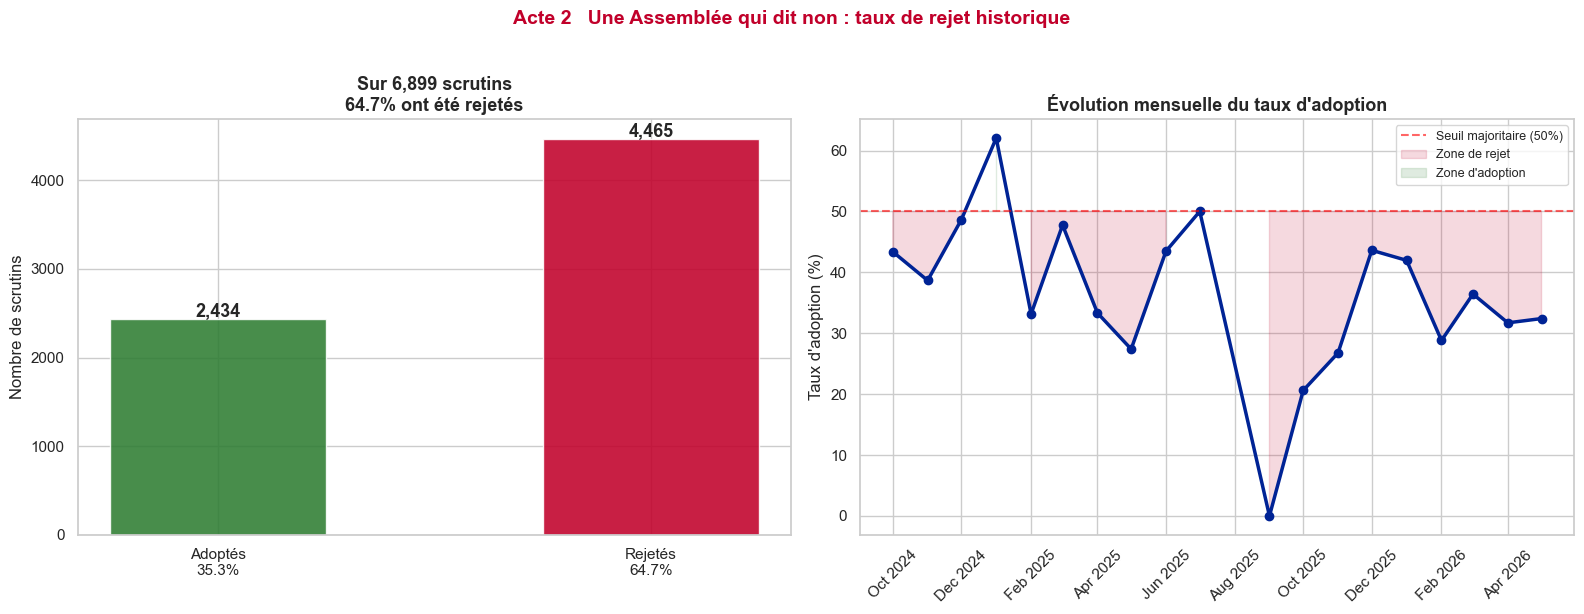

✅ Figure 4 sauvegardée


In [6]:
adopte_pct = df_scrutins["adopte"].mean() * 100
rejete_pct = 100 - adopte_pct

scrutins_mois = (
    df_scrutins
    .groupby(df_scrutins["date"].dt.to_period("M"))
    .agg(
        nb=("uid", "count"),
        taux_adoption=("adopte", "mean"),
        participation=("taux_participation", "mean")
    )
    .reset_index()
)
scrutins_mois["date"] = scrutins_mois["date"].dt.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

couleurs = ["#2E7D32", "#C1002A"]
valeurs  = [df_scrutins["adopte"].sum(), (~df_scrutins["adopte"]).sum()]
labels   = [f"Adoptés\n{adopte_pct:.1f}%", f"Rejetés\n{rejete_pct:.1f}%"]
bars = axes[0].bar(labels, valeurs, color=couleurs,
                   edgecolor="white", alpha=0.88, width=0.5)
for bar, val in zip(bars, valeurs):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f"{val:,}", ha="center", fontweight="bold", fontsize=13
    )
axes[0].set_ylabel("Nombre de scrutins")
axes[0].set_title(
    f"Sur {len(df_scrutins):,} scrutins\n"
    f"{rejete_pct:.1f}% ont été rejetés",
    fontsize=13, fontweight="bold"
)

axes[1].plot(
    scrutins_mois["date"],
    scrutins_mois["taux_adoption"] * 100,
    marker="o", color="#002395", linewidth=2.5
)
axes[1].axhline(50, color="red", linestyle="--",
                alpha=0.6, label="Seuil majoritaire (50%)")
axes[1].fill_between(
    scrutins_mois["date"],
    scrutins_mois["taux_adoption"] * 100, 50,
    where=scrutins_mois["taux_adoption"] * 100 < 50,
    alpha=0.15, color="#C1002A", label="Zone de rejet"
)
axes[1].fill_between(
    scrutins_mois["date"],
    scrutins_mois["taux_adoption"] * 100, 50,
    where=scrutins_mois["taux_adoption"] * 100 >= 50,
    alpha=0.15, color="#2E7D32", label="Zone d'adoption"
)
axes[1].set_ylabel("Taux d'adoption (%)")
axes[1].set_title("Évolution mensuelle du taux d'adoption",
                   fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle(
    "Acte 2   Une Assemblée qui dit non : taux de rejet historique",
    fontsize=14, fontweight="bold", y=1.02, color="#C1002A"
)
plt.tight_layout()
plt.savefig("../data/processed/04_taux_rejet.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 4 sauvegardée")

Activité et participation

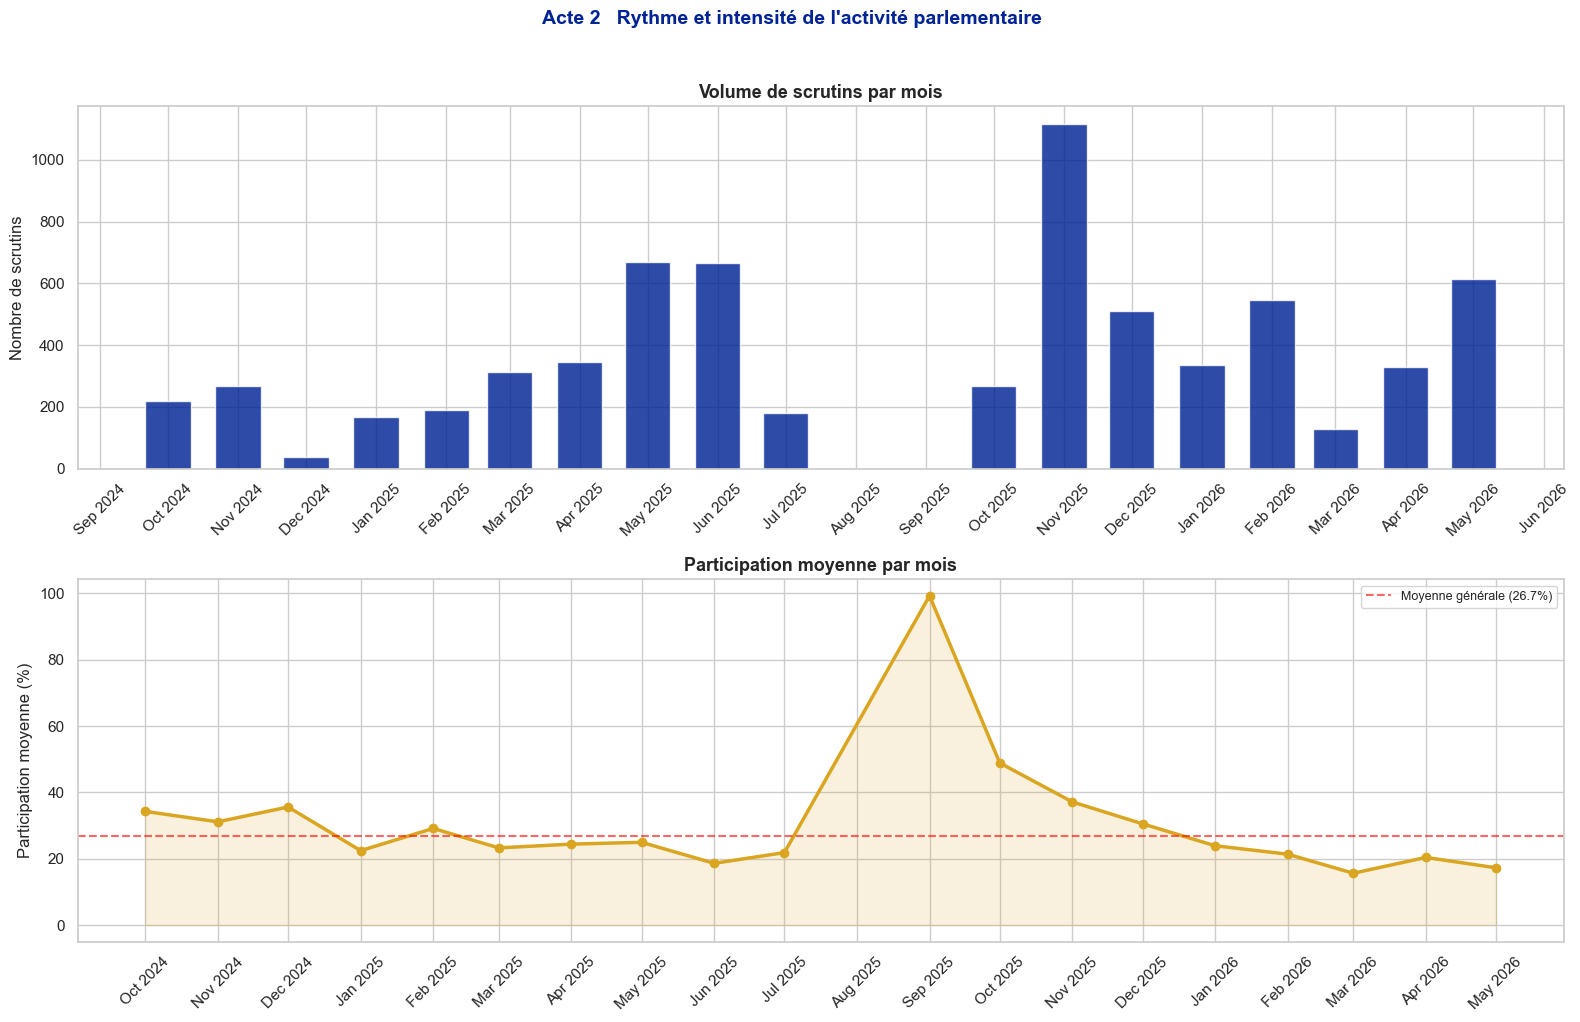

✅ Figure 5 sauvegardée


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].bar(
    scrutins_mois["date"], scrutins_mois["nb"],
    width=20, color="#002395", alpha=0.82, edgecolor="white"
)
axes[0].set_ylabel("Nombre de scrutins")
axes[0].set_title("Volume de scrutins par mois",
                   fontsize=13, fontweight="bold")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].plot(
    scrutins_mois["date"], scrutins_mois["participation"],
    marker="o", color="#DAA520", linewidth=2.5
)
axes[1].fill_between(
    scrutins_mois["date"], scrutins_mois["participation"],
    alpha=0.15, color="#DAA520"
)
axes[1].axhline(
    df_scrutins["taux_participation"].mean(),
    color="red", linestyle="--", alpha=0.6,
    label=f"Moyenne générale ({df_scrutins['taux_participation'].mean():.1f}%)"
)
axes[1].set_ylabel("Participation moyenne (%)")
axes[1].set_title("Participation moyenne par mois",
                   fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle(
    "Acte 2   Rythme et intensité de l'activité parlementaire",
    fontsize=14, fontweight="bold", y=1.02, color="#002395"
)
plt.tight_layout()
plt.savefig("../data/processed/05_activite_participation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 5 sauvegardée")

Anatomie des votes

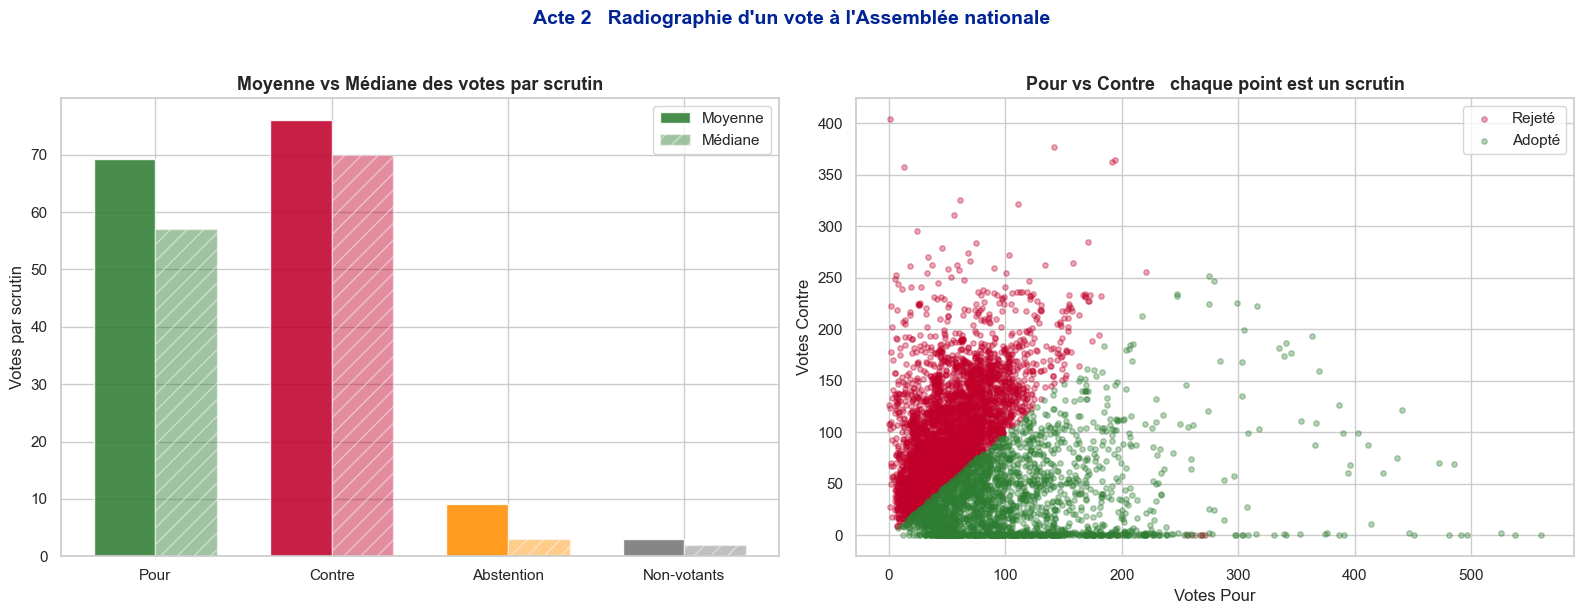

✅ Figure 6 sauvegardée


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

votes_data = pd.DataFrame({
    "Type":    ["Pour", "Contre", "Abstention", "Non-votants"],
    "Moyenne": [
        df_scrutins["pour"].mean(),
        df_scrutins["contre"].mean(),
        df_scrutins["abstention"].mean(),
        df_scrutins["non_votant"].mean()
    ],
    "Médiane": [
        df_scrutins["pour"].median(),
        df_scrutins["contre"].median(),
        df_scrutins["abstention"].median(),
        df_scrutins["non_votant"].median()
    ]
})
couleurs_votes = ["#2E7D32", "#C1002A", "#FF8F00", "#757575"]
x     = range(len(votes_data))
width = 0.35
axes[0].bar([i - width/2 for i in x], votes_data["Moyenne"],
            width, label="Moyenne", color=couleurs_votes,
            alpha=0.88, edgecolor="white")
axes[0].bar([i + width/2 for i in x], votes_data["Médiane"],
            width, label="Médiane", color=couleurs_votes,
            alpha=0.45, edgecolor="white", hatch="//")
axes[0].set_xticks(x)
axes[0].set_xticklabels(votes_data["Type"])
axes[0].set_ylabel("Votes par scrutin")
axes[0].set_title("Moyenne vs Médiane des votes par scrutin",
                   fontsize=13, fontweight="bold")
axes[0].legend()

adoptes = df_scrutins[df_scrutins["adopte"] == True]
rejetes = df_scrutins[df_scrutins["adopte"] == False]
axes[1].scatter(rejetes["pour"], rejetes["contre"],
                alpha=0.35, color="#C1002A", label="Rejeté", s=15)
axes[1].scatter(adoptes["pour"], adoptes["contre"],
                alpha=0.35, color="#2E7D32", label="Adopté", s=15)
axes[1].set_xlabel("Votes Pour")
axes[1].set_ylabel("Votes Contre")
axes[1].set_title("Pour vs Contre   chaque point est un scrutin",
                   fontsize=13, fontweight="bold")
axes[1].legend()

plt.suptitle(
    "Acte 2   Radiographie d'un vote à l'Assemblée nationale",
    fontsize=14, fontweight="bold", y=1.02, color="#002395"
)
plt.tight_layout()
plt.savefig("../data/processed/06_anatomie_votes.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 6 sauvegardée")

Scrutins serrés

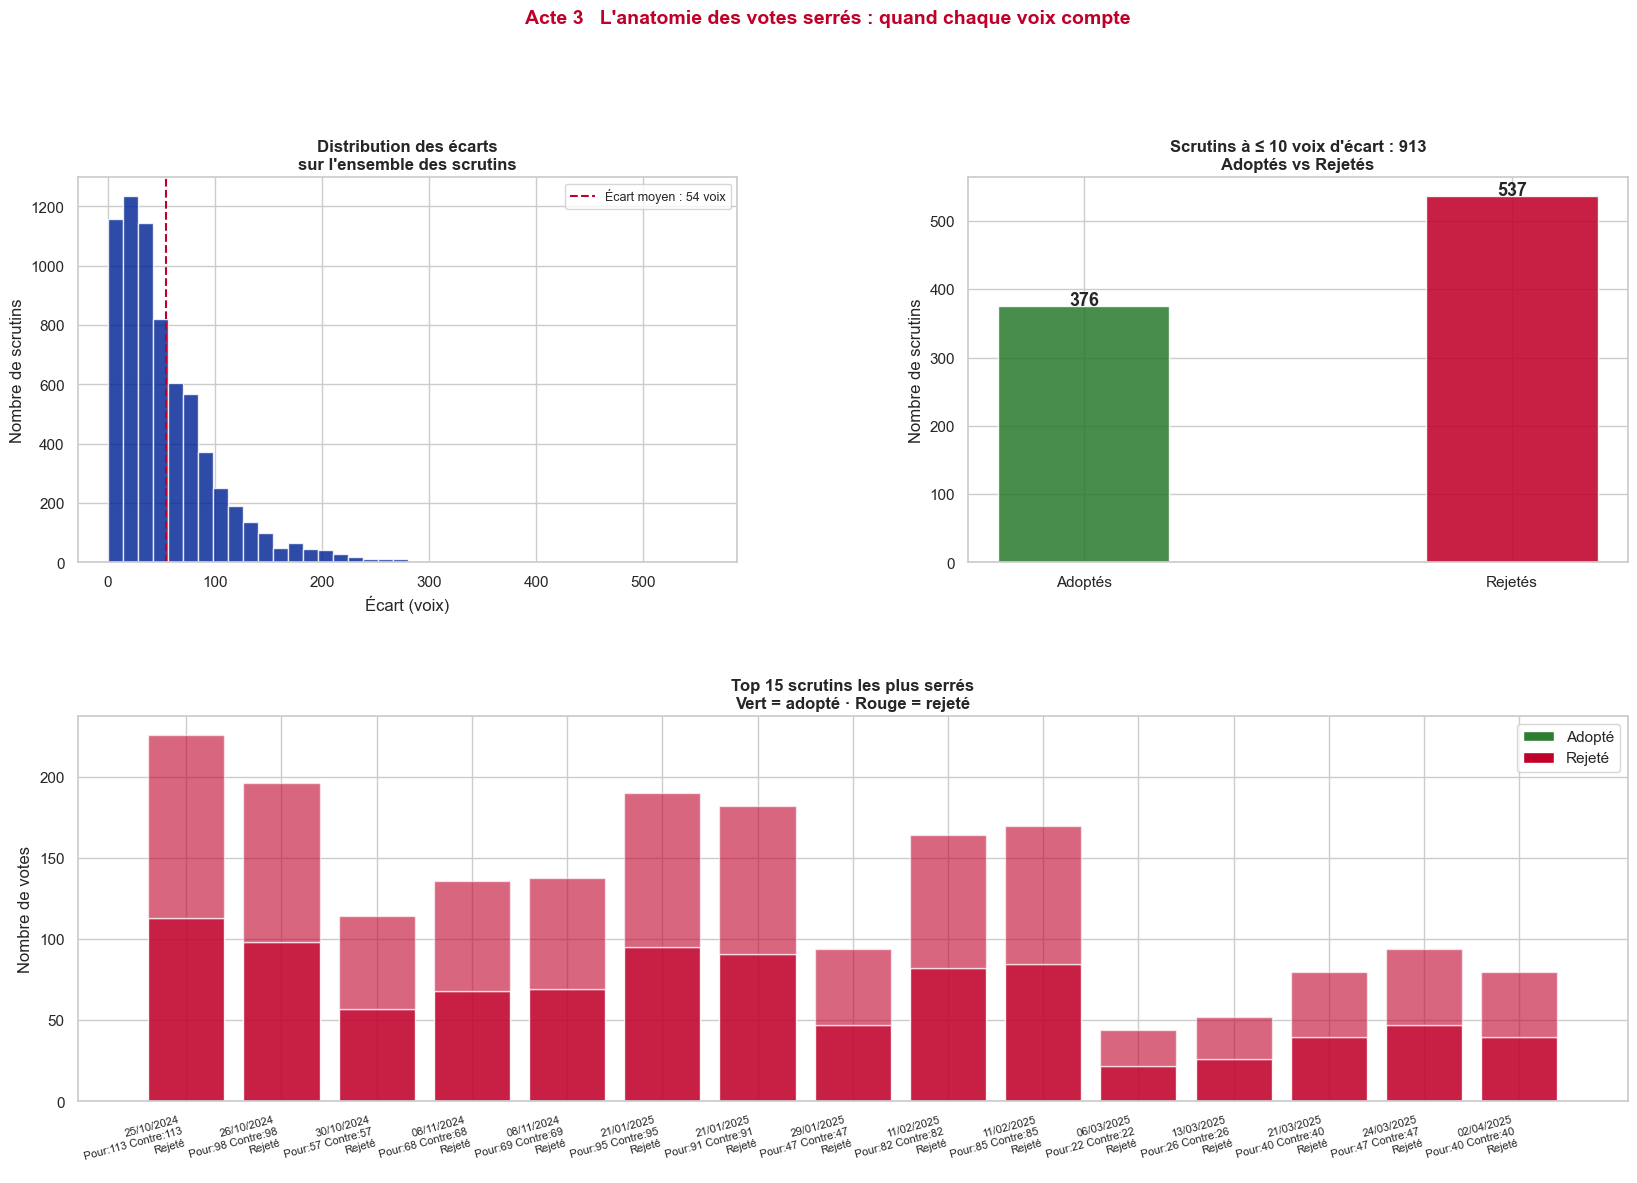

✅ Figure 7 sauvegardée

⚡ Scrutins à égalité parfaite (0 voix) : 50
⚡ Scrutins à ≤ 10 voix d'écart : 913


In [9]:
top_disputes = (
    df_scrutins
    .nsmallest(15, "ecart")
    [["date", "titre_court", "pour", "contre", "ecart", "sort", "adopte"]]
    .copy()
)
top_disputes["date_str"] = top_disputes["date"].dt.strftime("%d/%m/%Y")
top_disputes["couleur"]  = top_disputes["adopte"].map(
    {True: "#2E7D32", False: "#C1002A"}
).fillna("#757575")

tres_serres = df_scrutins[df_scrutins["ecart"] <= 10].copy()

fig = plt.figure(figsize=(20, 12))
gs  = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

ax1.hist(df_scrutins["ecart"].dropna(), bins=40,
         color="#002395", edgecolor="white", alpha=0.82)
ax1.axvline(df_scrutins["ecart"].mean(), color="#C1002A",
            linestyle="--",
            label=f"Écart moyen : {df_scrutins['ecart'].mean():.0f} voix")
ax1.set_xlabel("Écart (voix)")
ax1.set_ylabel("Nombre de scrutins")
ax1.set_title("Distribution des écarts\nsur l'ensemble des scrutins",
              fontsize=12, fontweight="bold")
ax1.legend(fontsize=9)

adoptes_serres = tres_serres["adopte"].sum()
rejetes_serres = (~tres_serres["adopte"]).sum()
bars = ax2.bar(
    ["Adoptés", "Rejetés"],
    [adoptes_serres, rejetes_serres],
    color=["#2E7D32", "#C1002A"],
    edgecolor="white", alpha=0.88, width=0.4
)
for bar, v in zip(bars, [adoptes_serres, rejetes_serres]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             str(v), ha="center", fontweight="bold", fontsize=13)
ax2.set_ylabel("Nombre de scrutins")
ax2.set_title(
    f"Scrutins à ≤ 10 voix d'écart : {len(tres_serres)}\n"
    f"Adoptés vs Rejetés",
    fontsize=12, fontweight="bold"
)

x_pos  = range(len(top_disputes))
colors = top_disputes["couleur"].tolist()
ax3.bar(x_pos, top_disputes["pour"],
        color=colors, edgecolor="white", alpha=0.88)
ax3.bar(x_pos, top_disputes["contre"],
        bottom=top_disputes["pour"],
        color=[c + "66" for c in colors],
        edgecolor="white", alpha=0.6)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(
    [f"{r['date_str']}\nPour:{r['pour']} Contre:{r['contre']}\n"
     f"{'Adopté' if r['adopte'] else 'Rejeté'}"
     for _, r in top_disputes.iterrows()],
    fontsize=8, rotation=15, ha="right"
)
ax3.set_ylabel("Nombre de votes")
ax3.set_title(
    "Top 15 scrutins les plus serrés\nVert = adopté · Rouge = rejeté",
    fontsize=12, fontweight="bold"
)
ax3.legend(handles=[
    mpatches.Patch(facecolor="#2E7D32", label="Adopté"),
    mpatches.Patch(facecolor="#C1002A", label="Rejeté")
], loc="upper right")

plt.suptitle(
    "Acte 3   L'anatomie des votes serrés : quand chaque voix compte",
    fontsize=14, fontweight="bold", y=1.02, color="#C1002A"
)
plt.savefig("../data/processed/07_scrutins_serres.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 7 sauvegardée")

print(f"\n⚡ Scrutins à égalité parfaite (0 voix) : "
      f"{len(df_scrutins[df_scrutins['ecart']==0])}")
print(f"⚡ Scrutins à ≤ 10 voix d'écart : {len(tres_serres)}")

Types de scrutins

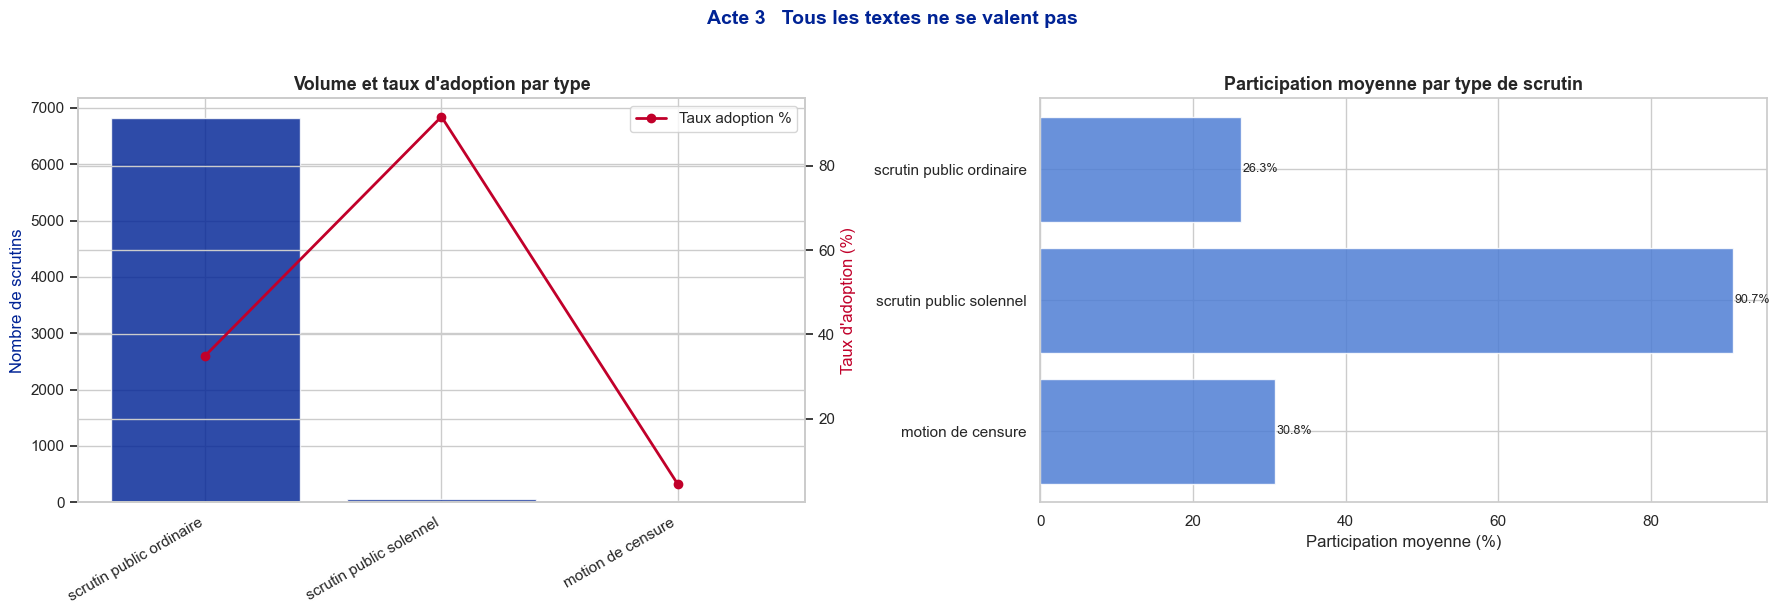

✅ Figure 8 sauvegardée


In [10]:
type_vote_stats = (
    df_scrutins
    .groupby("type_vote")
    .agg(
        nb=("uid", "count"),
        taux_adoption=("adopte", "mean"),
        participation_moy=("taux_participation", "mean"),
        ecart_moyen=("ecart", "mean")
    )
    .sort_values("nb", ascending=False)
    .head(8)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x    = range(len(type_vote_stats))
bars = axes[0].bar(x, type_vote_stats["nb"],
                   color="#002395", alpha=0.82, edgecolor="white")
ax2  = axes[0].twinx()
ax2.plot(x, type_vote_stats["taux_adoption"] * 100,
         color="#C1002A", marker="o", linewidth=2,
         label="Taux adoption %")
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    type_vote_stats["type_vote"], rotation=30, ha="right"
)
axes[0].set_ylabel("Nombre de scrutins", color="#002395")
ax2.set_ylabel("Taux d'adoption (%)", color="#C1002A")
axes[0].set_title("Volume et taux d'adoption par type",
                   fontsize=13, fontweight="bold")
ax2.legend(loc="upper right")

axes[1].barh(
    type_vote_stats["type_vote"],
    type_vote_stats["participation_moy"],
    color="#4f7ed4", edgecolor="white", alpha=0.85
)
for i, val in enumerate(type_vote_stats["participation_moy"]):
    axes[1].text(val + 0.2, i, f"{val:.1f}%", va="center", fontsize=9)
axes[1].set_xlabel("Participation moyenne (%)")
axes[1].set_title("Participation moyenne par type de scrutin",
                   fontsize=13, fontweight="bold")
axes[1].invert_yaxis()

plt.suptitle(
    "Acte 3   Tous les textes ne se valent pas",
    fontsize=14, fontweight="bold", y=1.02, color="#002395"
)
plt.tight_layout()
plt.savefig("../data/processed/08_types_scrutins.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 8 sauvegardée")

Corrélation entre variables des scrutins

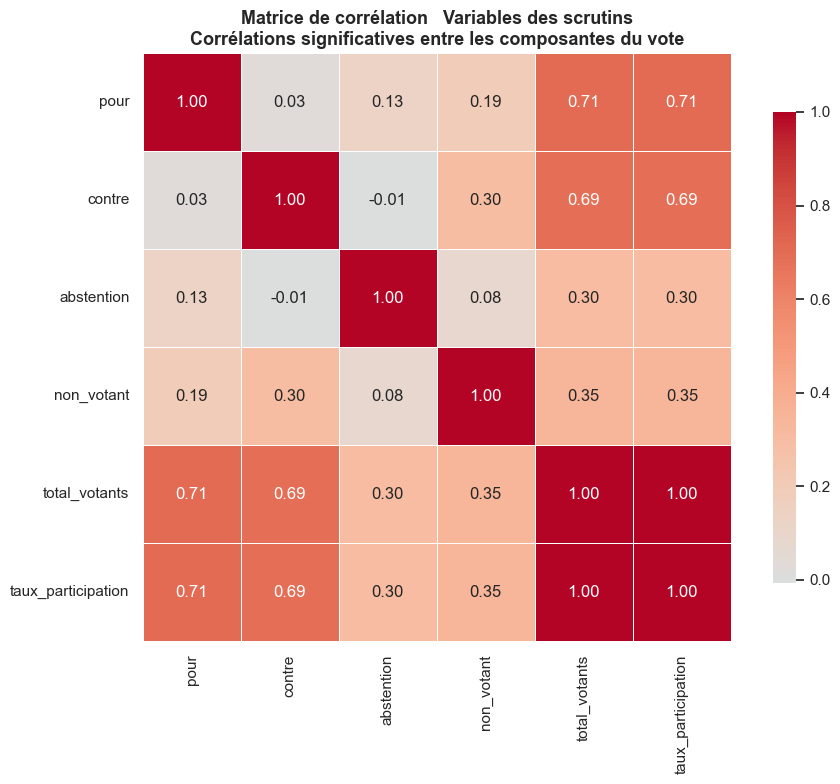

✅ Figure 9 sauvegardée

── CORRÉLATIONS NOTABLES ───────────────────────────
   pour ↔ total_votants : r=0.706
   pour ↔ taux_participation : r=0.706
   contre ↔ total_votants : r=0.692
   contre ↔ taux_participation : r=0.692
   total_votants ↔ taux_participation : r=1.000


In [11]:
df_corr = df_scrutins[[
    "pour", "contre", "abstention", "non_votant",
    "total_votants", "taux_participation"
]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(df_corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    df_corr,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title(
    "Matrice de corrélation   Variables des scrutins\n"
    "Corrélations significatives entre les composantes du vote",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../data/processed/09_correlation_scrutins.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 9 sauvegardée")

print(f"\n── CORRÉLATIONS NOTABLES ───────────────────────────")
for i in range(len(df_corr.columns)):
    for j in range(i+1, len(df_corr.columns)):
        val = df_corr.iloc[i, j]
        if abs(val) > 0.5:
            print(f"   {df_corr.columns[i]} ↔ {df_corr.columns[j]} : "
                  f"r={val:.3f}")

Résumé actes 2 et 3

In [12]:
mois_plus_actif  = scrutins_mois.loc[scrutins_mois["nb"].idxmax()]
scrutin_plus_serre = df_scrutins.loc[df_scrutins["ecart"].idxmin()]

print("=" * 55)
print("ACTES 2 & 3   SYNTHÈSE")
print("=" * 55)
print(f"""
🗳️  UNE ASSEMBLÉE QUI DIT NON
   Taux de rejet : {rejete_pct:.1f}%
   Taux d'adoption : {adopte_pct:.1f}%
   Participation moyenne : {df_scrutins['taux_participation'].mean():.1f}%
   Skewness participation : {df_scrutins['taux_participation'].skew():.3f}

📅  RYTHME LÉGISLATIF
   Mois le plus actif : {mois_plus_actif['date'].strftime('%B %Y')}
   ({mois_plus_actif['nb']:.0f} scrutins)
   Total : {len(df_scrutins):,} scrutins

⚡  VOTES SERRÉS
   Égalités parfaites (0 voix) : {len(df_scrutins[df_scrutins['ecart']==0])}
   Écart ≤ 10 voix : {len(tres_serres)}
   Scrutin le plus serré : écart de {scrutin_plus_serre['ecart']:.0f} voix

📊  TESTS STATISTIQUES
   t-test Pour vs Contre : p={p_ttest:.4f}
   Mann-Whitney U        : p={p_mwu:.4f}

💾  EXPORTS
   data/processed/scrutins_clean.csv
   data/processed/04_taux_rejet.png
   data/processed/05_activite_participation.png
   data/processed/06_anatomie_votes.png
   data/processed/07_scrutins_serres.png
   data/processed/08_types_scrutins.png
   data/processed/09_correlation_scrutins.png
""")

ACTES 2 & 3   SYNTHÈSE

🗳️  UNE ASSEMBLÉE QUI DIT NON
   Taux de rejet : 64.7%
   Taux d'adoption : 35.3%
   Participation moyenne : 26.7%
   Skewness participation : 1.195

📅  RYTHME LÉGISLATIF
   Mois le plus actif : November 2025
   (1117 scrutins)
   Total : 6,899 scrutins

⚡  VOTES SERRÉS
   Égalités parfaites (0 voix) : 50
   Écart ≤ 10 voix : 913
   Scrutin le plus serré : écart de 0 voix

📊  TESTS STATISTIQUES
   t-test Pour vs Contre : p=0.0000
   Mann-Whitney U        : p=0.0000

💾  EXPORTS
   data/processed/scrutins_clean.csv
   data/processed/04_taux_rejet.png
   data/processed/05_activite_participation.png
   data/processed/06_anatomie_votes.png
   data/processed/07_scrutins_serres.png
   data/processed/08_types_scrutins.png
   data/processed/09_correlation_scrutins.png

